This is same as lab5 - 05_Chat+Tool+Memory_langGraphAgentWithOllama copy.ipynb
Only addition here is Langsmith to trace the calls

To use LangSmith:
    - Login to LangSmith- https://smith.langchain.com
    - Then Click - Get started with Tracing and follow steps to
        - Create your API Key
        - Install dependencies ( pip install --pre -U langchain langchain-openai)
        - Configure environment 
    - Update your gpaph invoke with @traceable 

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

Add Memory

In [2]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver() # MemorySaver(): This is an in-memory database that stores the snapshots.

c:\Users\Arun.Manglick\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

Define Tool

In [4]:
from langchain.tools import tool

@tool
def latest_stock_price(symbol: str) -> float:

    '''Return the current price of a stock given the stock symbol
    :param symbol: stock symbol
    :return: current price of the stock
    '''
    return {
        "MSFT": 250.4,
        "AAPL": 270.4,
        "AMZN": 350.0,
        "RIL": 99.6
    }.get(symbol, 0.0)

mystockpricetools = [latest_stock_price]

Define Ollama as LLM

In [5]:
from langchain_ollama import ChatOllama

# Using the available model in your Ollama environment
llm = ChatOllama(model="gpt-oss:120b-cloud")
llm.invoke("Capital of France")


AIMessage(content='The capital of France is **Paris**.', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b-cloud', 'created_at': '2026-01-03T13:23:29.054971223Z', 'done': True, 'done_reason': 'stop', 'total_duration': 654746112, 'load_duration': None, 'prompt_eval_count': 70, 'prompt_eval_duration': None, 'eval_count': 56, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b-cloud', 'model_provider': 'ollama'}, id='lc_run--019b8406-f4ca-7852-86ac-bb6c9036e7ce-0', usage_metadata={'input_tokens': 70, 'output_tokens': 56, 'total_tokens': 126})

Extend LLM with defined Tool

In [6]:
# Extend llm with tools
llm_With_Tools = llm.bind_tools(mystockpricetools)
llm_With_Tools.invoke("What is the latest stock price of AAPL?")

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b-cloud', 'created_at': '2026-01-03T13:23:31.540068083Z', 'done': True, 'done_reason': 'stop', 'total_duration': 668323386, 'load_duration': None, 'prompt_eval_count': 151, 'prompt_eval_duration': None, 'eval_count': 46, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b-cloud', 'model_provider': 'ollama'}, id='lc_run--019b8407-02f5-7c83-a55e-ca3519d571ad-0', tool_calls=[{'name': 'latest_stock_price', 'args': {'symbol': 'AAPL'}, 'id': 'e8f2941c-91d4-4c09-b6ec-70532785cb56', 'type': 'tool_call'}], usage_metadata={'input_tokens': 151, 'output_tokens': 46, 'total_tokens': 197})

Define Chat Object and Chat Method

In [7]:
from typing import Annotated

class ChatState(TypedDict): 
    chatMessages: Annotated[list, add_messages]

def chatbotMessage(state: ChatState) -> ChatState:
    # Use the LLM bound with tools
    response = llm_With_Tools.invoke(state["chatMessages"])
    return {"chatMessages": [response]}

Define LangGraph Edges and Nodes

In [8]:
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(ChatState)
builder.add_node("chatbotMessage_node", chatbotMessage)

# Specify messages_key="chatMessages" for ToolNode
builder.add_node("tools_node", ToolNode(mystockpricetools, messages_key="chatMessages"))

builder.add_edge(START, "chatbotMessage_node") # Start edge

# Use a lambda to pass messages_key="chatMessages" to tools_condition
builder.add_conditional_edges(
    "chatbotMessage_node", 
    lambda state: tools_condition(state, messages_key="chatMessages"), 
    {"tools": "tools_node", END: END}
) # Conditional edges based on whether tool use is needed

# Code Explaination: builder.add_conditional_edges( ... 
# After the chatbot responds, the graph needs to decide where to go next.
    # lambda: Used here to pass your custom messages_key to the condition function.
    # tools_condition: A prebuilt function that checks the last message. If the LLM wants to use a tool, it returns "tools". If the LLM is finished, it returns END.
    # Mapping: If the condition returns "tools", the graph moves to tools_node. If it returns END, the process stops.

builder.add_edge("tools_node", "chatbotMessage_node") # Backward edge to continue chat after tool use
graph = builder.compile(checkpointer=memory)

# checkpointer=memory
# This is the key to giving your agent short-term memory.
# The Checkpointer: 
    # A checkpointer is a layer that saves the "state" of the graph (in your case, the chatMessages list) at every step.
    # Without a checkpointer, every call to graph.invoke() starts with a completely blank slate. 
    # With it, the graph can look up previous interactions and continue the conversation where it left off.

Display Graph

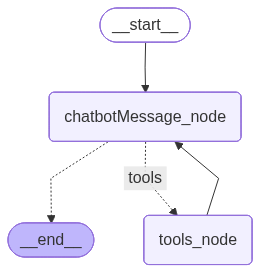

In [9]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

Example Talk to Chat Agent

In [10]:
from langsmith import traceable

@traceable
def run_chatgraph(message):
   config1 = { 'configurable': { 'thread_id': '1'} }
   result = graph.invoke({"chatMessages": [message]}, config=config1)
   return result["chatMessages"][-1].content

run_chatgraph("What is the price of AAPL Stocks?")

'The current price of Apple\u202fInc. (AAPL) stock is **$270.40** per share.'